In [1]:
import os
import sys
from collections import Counter

import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchinfo
import torchvision
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
from tqdm.notebook import tqdm
from tqdm.version import __version__ as tqdm__version__

torch.backends.cudnn.deterministic = True

In [2]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("CV2 version : ", cv2.__version__)
print("matplotlib version : ", matplotlib.__version__)
print("numpy version : ", np.__version__)
print("torch version : ", torch.__version__)
print("torchinfo version : ", torchinfo.__version__)
print("torchvision version : ", torchvision.__version__)
print("PIL version : ", PIL.__version__)
print("scikit-learn version: ", sklearn.__version__)
print("tqdm version: ", tqdm__version__)

Platform: win32
Python version: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
---
CV2 version :  4.13.0
matplotlib version :  3.10.8
numpy version :  2.0.1
torch version :  2.12.0.dev20260317+cu128
torchinfo version :  1.8.0
torchvision version :  0.26.0.dev20260317+cu128
PIL version :  11.1.0
scikit-learn version:  1.7.2
tqdm version:  4.67.3


The aim of this notebook is to identify wild

objectives include:

1. convert images from grayscale to RGB
2. resize images
3. standardization of images for training
4. build and train a simple neural network
5. save athe trained neural network
    

In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cuda device.


In [4]:
# Assign train_path the path to the training data.

data_path = os.path.join("data", "binary_class_data")
train_path = os.path.join(data_path, "train")

print("Data Directory:", data_path)
print("Training Data Directory:", train_path)

Data Directory: data\binary_class_data
Training Data Directory: data\binary_class_data\train


Each folder contain the labels of each class. i.e Blank and leopard (separated into distinct folders)

In [6]:
labels = os.listdir(train_path)
labels

['blank', 'leopard']

We want to build a model that distiguish between the image of a leopard and and a blank image

In [26]:
# Determine the number of blank images in the training data and assign the result to blank_images

leopard_path = os.path.join(train_path, "leopard")
leopard_images = os.listdir(leopard_path)
print("length of leopard images: ", len(leopard_images))

blank_path = os.path.join(train_path, "blank")
blank_images = os.listdir(blank_path)
print("length of blank images: ", len(blank_images))


length of leopard images:  2254
length of blank images:  2213


In [27]:
# Display the path of one image of the blank class and the leopard class.

leopard_image_name = leopard_images[10]
print(leopard_image_name)

leopard_image_path = os.path.join(leopard_path, leopard_image_name)
print(leopard_image_path)



blank_image_name = blank_images[1]
print(blank_image_name)

blank_image_path = os.path.join(blank_path, blank_image_name)
print(blank_image_path)

ZJ000063.jpg
data\binary_class_data\train\leopard\ZJ000063.jpg
ZJ000015.jpg
data\binary_class_data\train\blank\ZJ000015.jpg


In [28]:
# Print out the mode and size for the blank image sample

leopard_img_pil = Image.open(leopard_image_path)
print("Leopard image: ", leopard_img_pil.mode, leopard_img_pil.size)

blank_img_pil = Image.open(blank_image_path)
print("Blank image: ", blank_img_pil.mode, blank_img_pil.size)

Leopard image:  RGB (640, 335)
Blank image:  RGB (640, 360)


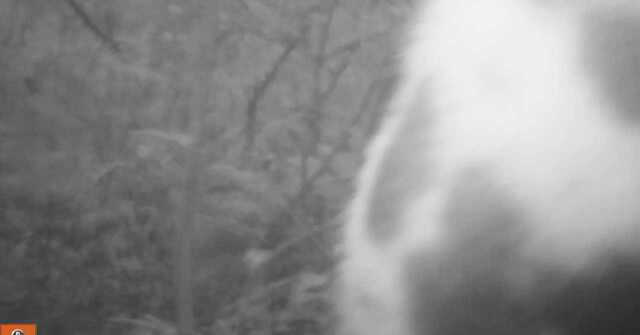

In [29]:
leopard_img_pil

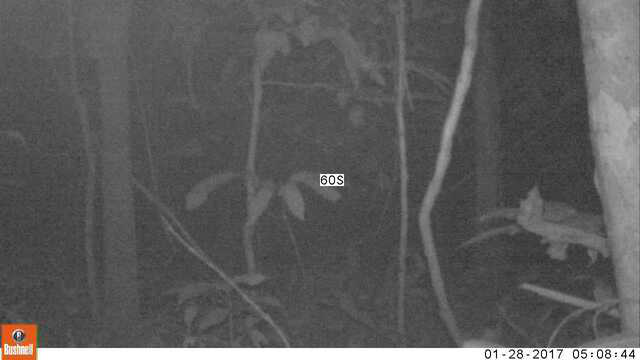

In [30]:
blank_img_pil

For building a model please note that all the image must be in the same mode ánd size

The following are the steps to achieve standardization through creating a processing pipeline
1. Convert image to RGB (that is if images are already not in RGB)
2. Resize images
3. Convert the images to pytorch tensors
4. Load the data and apply the transformation pipeline

In [31]:
# Create a transformation pipeline to standardize the images

class ToRGB:
    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

In [32]:
# note transforms.Compose is used to create the pipeline of the transformation to apply to the images

transform = transforms.Compose(
    [
        ToRGB(),  # Convert images to RGB format if not already
        transforms.Resize((224, 224)),  # Resize images to 224x224
        transforms.ToTensor() # Convert images to tensors

    ]
)

print(type(transform))
print(transform)

<class 'torchvision.transforms.transforms.Compose'>
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [33]:
# Load the data using datasets from the torchvision package.

# load the dataset using "ImageFolder"
dataset = datasets.ImageFolder(root=train_path, transform=transform)
print(dataset)

Dataset ImageFolder
    Number of datapoints: 4467
    Root location: data\binary_class_data\train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [34]:
# the dataset object has the attribute .classes which returns a list of distinct classes

dataset.classes

['blank', 'leopard']

In [38]:
# Prove that the only distinct values of im are 0 and 1 - this is done using a set data structure

im = dataset.imgs
print(im[0])  # would contain either 0 or 1 depending on the class labels

distinct_classes = {item[1] for item in im}    # note that item is in the form of item =(image_path, label)
print(distinct_classes)

('data\\binary_class_data\\train\\blank\\ZJ000013.jpg', 0)
{0, 1}


In [39]:
# perform train and validation split (80, 20 split)

g = torch.Generator()
g.manual_seed(42)

train_set, val_set = random_split(dataset, [0.8, 0.2], generator=g)



print(f"Length of training dataset: {len(train_set)}")
print(f"Length of validation dataset: {len(val_set)}")

Length of training dataset: 3574
Length of validation dataset: 893


In [40]:
# Explore the splited data to show the breakdown of the two classes

def count_class(dataset):
    c = Counter(x[1] for x in tqdm(dataset))
    class_to_index = dataset.dataset.class_to_idx
    return pd.Series({cat: c[idx] for cat, idx in class_to_index.items()})

In [42]:
train_counts = count_class(train_set)
train_counts

  0%|          | 0/3574 [00:00<?, ?it/s]

blank      1766
leopard    1808
dtype: int64

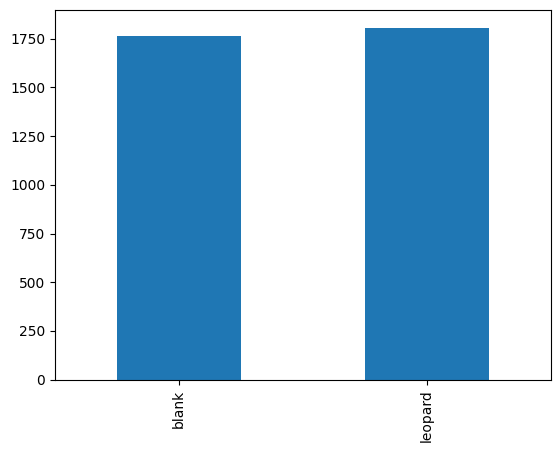

In [43]:
train_counts.sort_values().plot(kind="bar");

  0%|          | 0/893 [00:00<?, ?it/s]

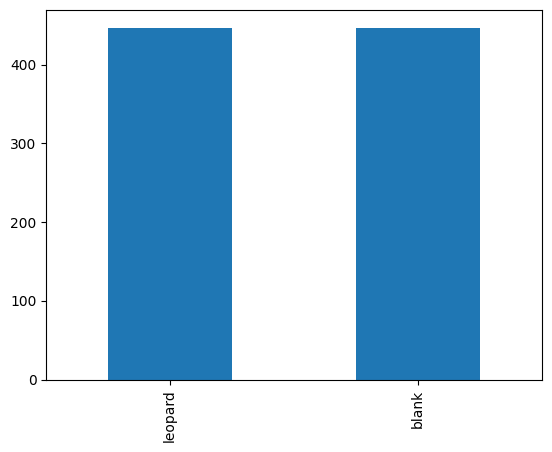

In [45]:
val_counts = count_class(val_set)

val_counts.sort_values().plot(kind="bar"); # plots a bar chart


In [46]:
# Create the validation and training set dataloader

# Important, don't change this!
g = torch.Generator()
g.manual_seed(42)

batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, generator=g)

val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, generator=g)

print(type(val_loader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [47]:
# get one sample bath of images and labels and make sure that the dimension matches what is expected
data_iter = iter(train_loader)
images, labels = next(data_iter)

# This gives you [batch_size, channels, height, width] for images
image_shape = images.shape
print("Shape of batch of images", image_shape)

# This gives you [batch_size] for labels
label_shape = labels.shape
print("Shape of batch of labels:", label_shape)

Shape of batch of images torch.Size([32, 3, 224, 224])
Shape of batch of labels: torch.Size([32])


In [48]:
labels

tensor([0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,
        0, 0, 1, 1, 0, 0, 0, 0])

In [49]:
# Flatten the images since a neural network cannot accept 3D Tensor

flatten = nn.Flatten()
tensor_flatten = flatten(images)

# Print the shape of the flattened tensor
print("Shape of flattened tensor:",tensor_flatten.shape)

Shape of flattened tensor: torch.Size([32, 150528])


In [50]:
# use the nn.Sequencial in Pytorch to apply all the layers of the network instead of doing manually

# Image size from our transformer
height = 224
width = 224

model = nn.Sequential(
    nn.Flatten(), #flattens the three-dimensional input tensors to one dimensional tensor that the next layer expects
    nn.Linear(3 * height * width, 512), # standard dense, or fully-connected, layer. Takes two arguments, the number of inputs coming into this layer and the number of outputs produced by this layer.
    nn.ReLU(), # performs the rectified linear unit activation. Activation functions are necessary for neural networks to work, and ReLU is a popular choice.
    nn.Linear(512, 128),
    nn.ReLU(),
)

print("model type:", type(model))
print("model structure:")
print(model)


model type: <class 'torch.nn.modules.container.Sequential'>
model structure:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=150528, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=128, bias=True)
  (4): ReLU()
)


In [51]:
# Create the ouput layer

output_layer = nn.Linear(128, 2)
model.append(output_layer)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=150528, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=2, bias=True)
)


In [52]:
# use model.to function to place the model on the device
model.to(device)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=150528, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=2, bias=True)
)


In [53]:
summary(model, input_size=(batch_size, 3, height, width))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 2]                   --
├─Flatten: 1-1                           [32, 150528]              --
├─Linear: 1-2                            [32, 512]                 77,070,848
├─ReLU: 1-3                              [32, 512]                 --
├─Linear: 1-4                            [32, 128]                 65,664
├─ReLU: 1-5                              [32, 128]                 --
├─Linear: 1-6                            [32, 2]                   258
Total params: 77,136,770
Trainable params: 77,136,770
Non-trainable params: 0
Total mult-adds (G): 2.47
Input size (MB): 19.27
Forward/backward pass size (MB): 0.16
Params size (MB): 308.55
Estimated Total Size (MB): 327.98

In [54]:
# define the loss function or error metric (for this we use cross entopy)

loss_fn = nn.CrossEntropyLoss()


In [55]:
# Define a optimizer. Helps to adjust the model's parameters to try to minimize the loss function. For this the Adam optimize.
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [56]:
# Define a function that encapsulates the training process

def train_epoch(model, optimizer, loss_fn, data_loader, device="cpu"):
    # We'll report the loss function's average value at the end of the epoch.
    training_loss = 0.0

    # The train method simply sets the model in training mode. No training
    # has happened.
    model.train()

    # We iterate over all batches in the training set to complete one epoch
    for inputs, targets in tqdm(data_loader, desc="Training", leave=False):
        # Sets the gradients to zero. We need to do this every time.
        optimizer.zero_grad()

        # Unpack images (X) and labels (y) from the batch and add those
        # tensors to the specified device.
        inputs = inputs.to(device)
        targets = targets.to(device)

        # We make a forward pass through the network and obtain the logits.
        # With the logits, we can calculate our loss.
        output = model(inputs)
        loss = loss_fn(output, targets)

        # After calculating our loss, we calculate the numerical value of
        # the derivative of our loss function with respect to all the
        # trainable model weights. Once we have the gradients calculated,
        # we let the optimizer take a "step", in other words, update or
        # adjust the model weights.
        loss.backward()
        optimizer.step()

        # We increment the training loss for the current batch
        training_loss += loss.data.item() * inputs.size(0)

    # We calculate the training loss over the completed epoch
    return training_loss / len(data_loader.dataset)

In [57]:
loss_value = train_epoch(model, optimizer, loss_fn, train_loader, device)
print(f"The average loss during the training epoch was {loss_value:.2f}.")

Training:   0%|          | 0/112 [00:00<?, ?it/s]

The average loss during the training epoch was 3.23.


In [58]:
# if we train our model again it won't start from the scratch but rather resumes from the current weights and continues to adjust them to improve the model

loss_value = train_epoch(model, optimizer, loss_fn, train_loader, device)
print(f"The average loss during the training epoch was {loss_value:.2f}.")

Training:   0%|          | 0/112 [00:00<?, ?it/s]

The average loss during the training epoch was 0.68.


In [59]:
# use the model to make predictions

def predict(model, data_loader, device="cpu"):
    # This tensor will store all of the predictions.
    all_probs = torch.tensor([]).to(device)

    # We set the model to evaluation mode. This mode is the opposite of
    # train mode we set in the train_epoch function.
    model.eval()

    # Since we're not training, we don't need any gradient calculations.
    # This tells PyTorch not to calculate any gradients, which speeds up
    # some calculations.
    with torch.no_grad():

        # Again, we iterate over the batches in the data loader and feed
        # them into the model for the forward pass.
        for inputs, targets in tqdm(data_loader, desc="Predicting", leave=False):
            inputs = inputs.to(device)
            output = model(inputs)

            # The model produces the logits.  This softmax function turns the
            # logits into probabilities.  These probabilities are concatenated
            # into the `all_probs` tensor.
            probs = F.softmax(output, dim=1)
            all_probs = torch.cat((all_probs, probs), dim=0)

    return all_probs

In [60]:
probabilities_train = predict(model, train_loader, device)
print(probabilities_train.shape) 

Predicting:   0%|          | 0/112 [00:00<?, ?it/s]

torch.Size([3574, 2])


In [61]:
len(train_loader.dataset)

3574

In [62]:
# Make predictions for each row of the validation data

probabilities_val = predict(model, val_loader, device)
print(probabilities_val.shape)

Predicting:   0%|          | 0/28 [00:00<?, ?it/s]

torch.Size([893, 2])


In [64]:
#returned probabilities
print(probabilities_train[0])

tensor([0.3904, 0.6096], device='cuda:0')


In [65]:
# sum of probabilities
probabilities_train[0].sum()

tensor(1.0000, device='cuda:0')

In [66]:
# print probabilities of the second row
probabilities_val[1]

tensor([0.2435, 0.7565], device='cuda:0')

In [68]:
#sum of probabilities to show they are equal to 1
total_probability = probabilities_val[1].sum()
print(f"Sum of probabilities: {total_probability.item()}")

Sum of probabilities: 1.0


In [69]:
#predicting of the labels

predictions_train = torch.argmax(probabilities_train, dim=1)

print(f"Predictions shape: {predictions_train.shape}")
print(f"First 10 predictions: {predictions_train[:10]}")

Predictions shape: torch.Size([3574])
First 10 predictions: tensor([1, 1, 0, 1, 0, 1, 1, 1, 0, 1], device='cuda:0')


In [70]:
# predicting the validation set
predictions_val = torch.argmax(probabilities_val, dim=1)

print(f"Predictions shape: {predictions_val.shape}")
print(f"First 10 predictions: {predictions_val[:10]}")

Predictions shape: torch.Size([893])
First 10 predictions: tensor([1, 1, 1, 1, 0, 1, 1, 0, 1, 1], device='cuda:0')


In [71]:
# Accuracy of the training data
targets_train = torch.cat([labels for _, labels in train_loader]).to(device)
is_correct_train = torch.eq(predictions_train, targets_train)
total_correct_train = torch.sum(is_correct_train).item()
accuracy_train = total_correct_train / len(train_loader.dataset)

print(f"Accuracy on the training data: {accuracy_train}")

Accuracy on the training data: 0.5067151650811416


In [72]:
# Accuracy on the validation data

targets_val = torch.cat([labels for _, labels in val_loader]).to(device)
is_correct_val = torch.eq(predictions_val, targets_val)
total_correct_val = torch.sum(is_correct_val).item()
accuracy_val = total_correct_val/len(val_loader.dataset)

print(f"Accuracy on the validation data: {accuracy_val}")

Accuracy on the validation data: 0.6976483762597985


In [73]:
# Go through the all the data and compute the loss and number of correct predictions

def score(model, data_loader, loss_fn, device="cpu"):
    # Initialize the total loss (cross entropy) and the number of correct
    # predictions. We'll increment these values as we loop through the
    # data.
    total_loss = 0
    total_correct = 0

    # We set the model to evaluation mode. This mode is the opposite of
    # train mode we set in the train_epoch function.
    model.eval()

    # Since we're not training, we don't need any gradient calculations.
    # This tells PyTorch not to calculate any gradients, which speeds up
    # some calculations.
    with torch.no_grad():
        # We iterate over the batches in the data loader and feed
        # them into the model for the forward pass.
        for inputs, targets in tqdm(data_loader, desc="Scoring", leave=False):
            inputs = inputs.to(device)
            output = model(inputs)

            # Calculating the loss function for this batch
            targets = targets.to(device)
            loss = loss_fn(output, targets)
            total_loss += loss.data.item() * inputs.size(0)

            # Calculating the correct predictions for this batch
            correct = torch.eq(torch.argmax(output, dim=1), targets)
            total_correct += torch.sum(correct).item()

    return total_loss / len(data_loader.dataset), total_correct / len(
        data_loader.dataset
    )

In [74]:
loss_train, accuracy_train = score(model, train_loader, loss_fn, device)
print(f"Training accuracy from score function: {accuracy_train}")

Scoring:   0%|          | 0/112 [00:00<?, ?it/s]

Training accuracy from score function: 0.7020145495243425


In [75]:
# Use the score function on the validation data, and check that we get the same accuracy as we computed above.

loss_val, accuracy_val = score(model, val_loader, loss_fn, device)
print(f"Validation accuracy from score function: {accuracy_val}")

Scoring:   0%|          | 0/28 [00:00<?, ?it/s]

Validation accuracy from score function: 0.6976483762597985


In [76]:
# specify how many epoch we want to train for


def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=20, device="cpu"):

    for epoch in range(1, epochs + 1):
        # Run train_epoch once, and capture the training loss.
        training_loss = train_epoch(model, optimizer, loss_fn, train_loader, device)

        # Score the model on the validation data.
        validation_loss, validation_accuracy = score(model, val_loader, loss_fn, device)

        print(
            f"Epoch: {epoch}, Training Loss: {training_loss:.2f}, "
            f"Validation Loss: {validation_loss:.2f}, Validation Accuracy: {validation_accuracy:.2f}"
        )

In [77]:
# Now that we've defined the function for training, let's use it.
train(model, optimizer, loss_fn, train_loader, val_loader, epochs=5, device=device)

Training:   0%|          | 0/112 [00:00<?, ?it/s]

Scoring:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch: 1, Training Loss: 0.64, Validation Loss: 0.83, Validation Accuracy: 0.55


Training:   0%|          | 0/112 [00:00<?, ?it/s]

Scoring:   0%|          | 0/28 [00:00<?, ?it/s]

...

Scoring:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch: 4, Training Loss: 0.57, Validation Loss: 0.49, Validation Accuracy: 0.77


Training:   0%|          | 0/112 [00:00<?, ?it/s]

Scoring:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch: 5, Training Loss: 0.56, Validation Loss: 0.55, Validation Accuracy: 0.70


In [78]:
# train for 5 epochs again
train(model, optimizer, loss_fn, train_loader, val_loader, epochs=5, device=device)

Training:   0%|          | 0/112 [00:00<?, ?it/s]

Scoring:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch: 1, Training Loss: 0.54, Validation Loss: 0.68, Validation Accuracy: 0.64


Training:   0%|          | 0/112 [00:00<?, ?it/s]

Scoring:   0%|          | 0/28 [00:00<?, ?it/s]

...

Scoring:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch: 4, Training Loss: 0.53, Validation Loss: 0.46, Validation Accuracy: 0.78


Training:   0%|          | 0/112 [00:00<?, ?it/s]

Scoring:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch: 5, Training Loss: 0.51, Validation Loss: 0.68, Validation Accuracy: 0.51
